# CosmUFR Run 4 — quickstart

Infers eight cosmological parameters from the matter power spectrum at two redshifts.

This notebook does four things:

1. Loads the released checkpoint and verifies its hash.
2. Runs inference and shows the result against known truth.
3. **Audits the model**, which is the most interesting part: the belief-settling core this architecture is named for never received a gradient during training.
4. Reproduces the published results table from a benchmark that ships with the repository.

Runtime, Run all takes about two minutes on a free Colab CPU.

**Before you read any output:** the reported uncertainties are a clamp constant, not a prediction. Do not use them as error bars. Section 3 shows why.

## 0. Install

In [1]:
# Colab: clones and installs. Inside an existing checkout: does nothing.
import os, subprocess, sys

try:
    import cosmufr                       # already importable, nothing to do
except ImportError:
    if not os.path.isdir('cosmufr-run4'):
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/arajgor1/cosmufr-run4'], check=True)
    os.chdir('cosmufr-run4')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-e', '.[demo]'],
                   check=True)
    import cosmufr

print('cosmufr', cosmufr.__version__, 'ready')

cosmufr 2.0.0 ready


## 1. Load the model and verify the checkpoint

In [2]:
import hashlib
import numpy as np
import cosmufr
from huggingface_hub import hf_hub_download

EXPECTED = '5db09d4ff02316c60a43e08fa242223d3243f4f224b625798eaf385151150fc1'

ckpt = os.environ.get('COSMUFR_CKPT') or hf_hub_download(
    repo_id='arajgor1/cosmufr-run4', filename='best.pt')

h = hashlib.sha256()
with open(ckpt, 'rb') as f:
    for chunk in iter(lambda: f.read(1 << 20), b''):
        h.update(chunk)
print('sha256  ', h.hexdigest())
print('expected', EXPECTED)
assert h.hexdigest() == EXPECTED, 'checkpoint does not match the released weights'

model = cosmufr.load_model(ckpt_path=ckpt, device='cpu')
print(f'\nloaded {sum(p.numel() for p in model.parameters()):,} parameters')

sha256   5db09d4ff02316c60a43e08fa242223d3243f4f224b625798eaf385151150fc1
expected 5db09d4ff02316c60a43e08fa242223d3243f4f224b625798eaf385151150fc1



loaded 136,194,617 parameters


## 2. Run inference

The benchmark ships with the repository, so the truth is known and you can see the residual directly.

In [3]:
bench = cosmufr.load_benchmark()
print(f'benchmark: {len(bench):,} spectra from {len(bench.source_counts())} sources')
print(bench.source_counts())

i = 0
result = cosmufr.infer(bench.pk_z0[i], bench.pk_z047[i], model=model)
truth = bench.params[i]

print(f"\n{'param':<6}{'predicted':>12}{'true':>12}{'residual':>12}{'sigma':>10}")
print('-' * 52)
for j, lbl in enumerate(cosmufr.PARAM_LABELS):
    v, t, s = result.params_array[j], truth[j], result.sigmas_array[j]
    flag = '  <- clamp floor' if abs(s - 0.1) < 1e-6 else ''
    print(f'{lbl:<6}{v:>12.5f}{t:>12.5f}{v-t:>+12.5f}{s:>10.4f}{flag}')

benchmark: 6,000 spectra from 13 sources
{'camb_nl': 31, 'bacco': 872, 'bcemu': 887, 'dark_emulator': 168, 'spk': 899, 'bacco_neutrino': 851, 'bacco_full8': 910, 'bcemu_neutrino': 341, 'bacco_multiz': 926, 'camels_simba': 1, 'camels_astrid_x': 8, 'quijote_lh': 1, 'ns_grid': 105}



param    predicted        true    residual     sigma
----------------------------------------------------
Om         0.38680     0.38442    +0.00239    0.1000  <- clamp floor
s8         0.67322     0.67277    +0.00044    0.1000  <- clamp floor
h          0.66863     0.67110    -0.00247    0.1000  <- clamp floor
ns         0.96181     0.96240    -0.00059    0.1000  <- clamp floor
Ob         0.04886     0.04860    +0.00026    0.1000  <- clamp floor
w0        -0.99591    -1.00000    +0.00409    0.1000  <- clamp floor
mv         0.00039     0.00000    +0.00039    0.1000  <- clamp floor
wa         0.00208     0.00000    +0.00208    0.1000  <- clamp floor


Notice the sigma column. Every entry is 0.1, on every input. That is the clamp floor of the uncertainty head, not a prediction. Section 3 explains why.

Determinism check: three identical calls should give bit-identical parameters.

In [4]:
runs = [cosmufr.infer(bench.pk_z0[i], bench.pk_z047[i], model=model).params_array
        for _ in range(3)]
print('bitwise identical across 3 runs:',
      np.array_equal(runs[0], runs[1]) and np.array_equal(runs[0], runs[2]))

bitwise identical across 3 runs: True


## 3. The audit

This is the part worth your attention.

CosmUFR was designed around a belief-settling core: encode the spectrum into a 1024-dimensional belief, then refine it through 16 steps of gradient descent on a learned energy. That refinement was the research claim.

A `Linear` bias that has taken even one optimizer step essentially never returns to exactly `0.0`. Here is what the released weights show.

In [5]:
audit = cosmufr.weight_audit(model)
print(audit.table())
print('\nUntrained modules on the default inference path:',
      audit.untrained_on_default_path)

Per-module weight audit

A Linear layer that has taken even one optimizer step essentially
never has a bias of exactly 0.0. Modules below with every bias at
exactly zero never received a gradient.

module                  on path  n Linear   biases == 0   max |bias|     verdict
--------------------------------------------------------------------------------
belief_proposal             yes        10     10/10        0.000e+00   UNTRAINED
belief_proposal_seq          no        10      0/10        7.374e-02     trained
constraint_head             yes         6      0/6         1.456e+01     trained
dyn_energy_head             yes         6      0/6         1.456e+01     trained
gen_head                    yes        18      0/18        8.653e-01     trained
halo_head                   yes         6      6/6         0.000e+00   UNTRAINED
obs_encoder                 yes        10     10/10        0.000e+00   UNTRAINED
obs_encoder_single           no        10      0/10        1.590e-02     

Eighty-four biases are still bit-exactly zero after forty epochs. The encoder, the belief proposal network and the settling core never received a gradient. What trained is the read-out heads, which learn to read a fixed random projection of the input.

The consequence is visible in the settling loop.

In [6]:
report = cosmufr.settling_report(model, bench.pk_z0[i], bench.pk_z047[i])
print(report.summary())

Settling report (16 refinement steps)

  belief movement    : 0.1132% of norm
  cosine(b_hat, b*)  : 0.999999
  energy at step 0   : -926537.3750
  energy at step 16  : -926537.3750
  energy drop        : 0.000000e+00   (0.0 float32 ULP at E = -926537)

  param        step 0     step 16       drift   % of value
  ------------------------------------------------------
  Om          0.38708     0.38680    2.74e-04       0.071%
  s8          0.67244     0.67322    7.73e-04       0.115%
  h           0.66860     0.66863    2.92e-05       0.004%
  ns          0.96171     0.96181    1.01e-04       0.011%
  Ob          0.04885     0.04886    9.57e-06       0.020%
  w0         -0.99579    -0.99591    1.20e-04       0.012%
  mv          0.00039     0.00039    8.77e-06       2.277%
  wa          0.00221     0.00208    1.27e-04       5.747%

Interpretation: the settling loop runs, but it moves the belief by a
fraction of a percent and the energy changes by a couple of float32
resolution steps -- 

The energy changes by one float32 unit at the magnitude it operates at, which is the smallest change that number can represent. The refinement runs and does nothing.

You can see the same thing from the architecture alone, with no checkpoint at all. One synthetic training step on a freshly initialized model:

In [7]:
import torch
from cosmufr.config import CosmUFRConfig
from cosmufr.model import CosmUFRLite

fresh = CosmUFRLite(CosmUFRConfig())
fresh.train(); fresh.zero_grad(set_to_none=True)
torch.manual_seed(0)
obs = torch.randn(8, fresh.cfg.d_obs) * 0.5 + 2.0
out = fresh(obs, return_full=False)
torch.nn.functional.mse_loss(out['params'], torch.rand(8, 8)).backward()

got = sorted({n.split('.')[0] for n, p in fresh.named_parameters()
              if p.grad is not None and p.grad.norm() > 0})
print('modules that received any gradient:', got)
print('\nEverything else is severed by the detach() in SettlingCore.forward.')

modules that received any gradient: ['param_head']

Everything else is severed by the detach() in SettlingCore.forward.


### Why the uncertainties are constant

In [8]:
sig = np.stack([cosmufr.infer(bench.pk_z0[j], bench.pk_z047[j],
                              model=model).sigmas_array
                for j in range(0, 40, 8)])
print(cosmufr.uncertainty_audit(sig).table())

Uncertainty audit

UncertaintyHead returns clamp(softplus(net(b)) + 1e-2, max=4.0),
so the smallest sigma it can emit is sqrt(1e-2) = 0.1.
A parameter sitting at that floor for every input is reporting the
clamp constant, not a prediction.

param     mean sigma         std   at floor
-------------------------------------------
Om          0.100000   4.470e-08     100.0%
s8          0.100000   4.470e-08     100.0%
h           0.100000   5.075e-08     100.0%
ns          0.100000   4.470e-08     100.0%
Ob          0.100000   4.175e-08     100.0%
w0          0.100000   4.470e-08     100.0%
mv          0.103230   6.460e-03      80.0%
wa          0.100000   1.609e-07     100.0%


## 4. Reproduce the published table

The original Run 4 numbers were computed on a validation split that existed only on the author's training infrastructure, so nobody could check them. This benchmark ships in the repository. Your numbers should match `reports/honest_eval.json` to within 1e-6.

This cell takes about a minute on a Colab CPU.

In [9]:
ev = cosmufr.evaluate(model, bench)
print(ev.table())
print()
print(ev.source_table())
for n in ev.notes:
    print('\nNote:', n)

CosmUFR Run 4 on the bundled benchmark (N = 6,000)

param      R2 (all)   R2 where it varies       RMSE
---------------------------------------------------
Om           0.6873               0.6895    0.02884
s8           0.7384               0.7366    0.02949
h            0.4751               0.4768    0.04128
ns           0.3309               0.3363    0.02188
Ob           0.3532               0.3533    0.00457
w0           0.5992               0.6676    0.02453
mv           0.4099               0.0233    0.09903
wa           0.1483               0.1736    0.06315

'R2 where it varies' excludes sources that hold the parameter at a
fiducial constant. R2 is a ratio against the variance of the truth,
so on a pinned slice it measures nothing. m_nu is the parameter this
matters most for: it looks competent in the left column only because
most of the corpus has m_nu = 0.

source                  n        Om      s8       h      ns      Ob      w0      mv      wa
----------------------------

Two things to read off that table.

**Neutrino mass.** It looks competent in the left column and is 0.011 in the right one. R-squared divides by the variance of the truth, so on data where the neutrino mass is pinned at zero, predicting near-zero scores well without recovering anything. The model does not constrain it.

**`bacco_multiz`.** Fifteen percent of the validation set, scoring zero on everything. Its z=0.47 spectra are self-paired copies of its z=0 spectra, so both input channels are identical and carry no growth information. That is a data-generation defect, and it is what drags the aggregate down. On sources with sound data, Omega_m recovery reaches 0.98 to 0.99.

## 5. Figures

Six figures, all from real tensors. Note that the P(k) panel shows a flat line: the generative head returns a constant, not a reconstruction.


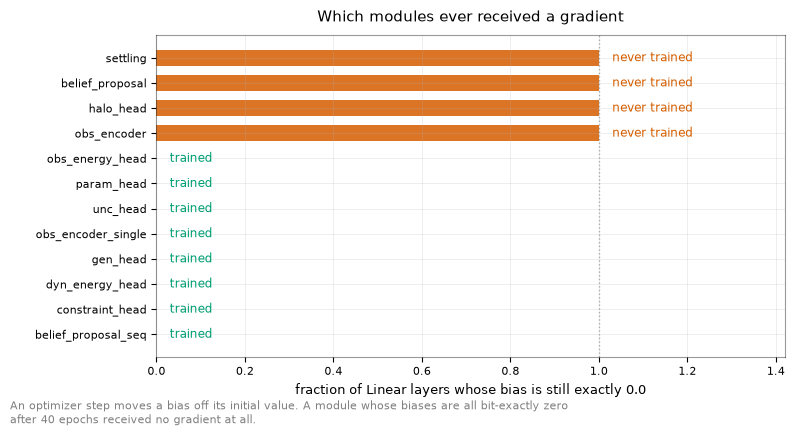

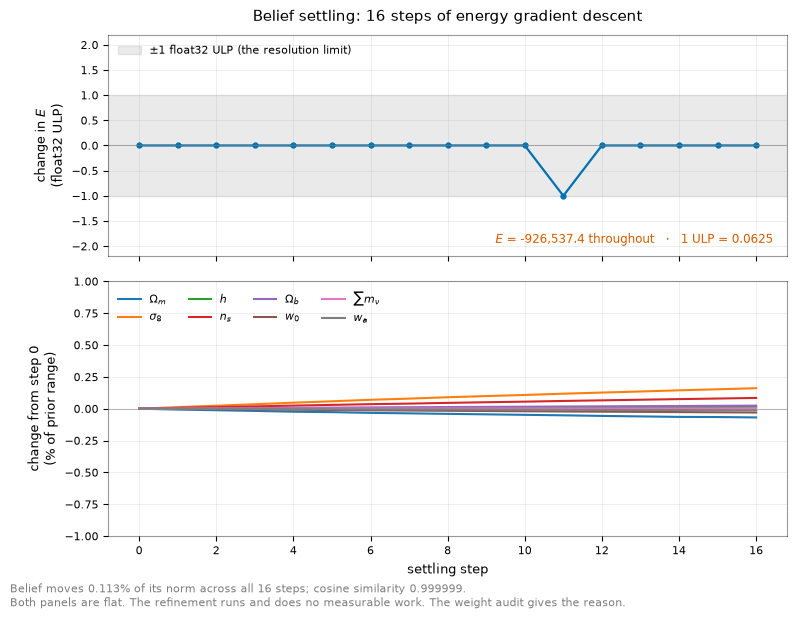

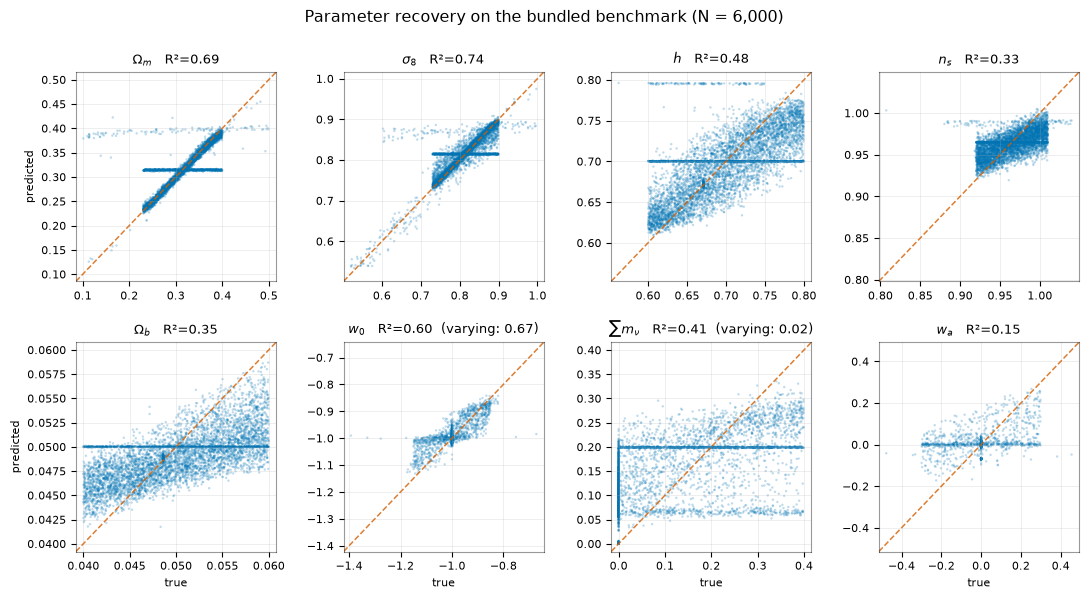

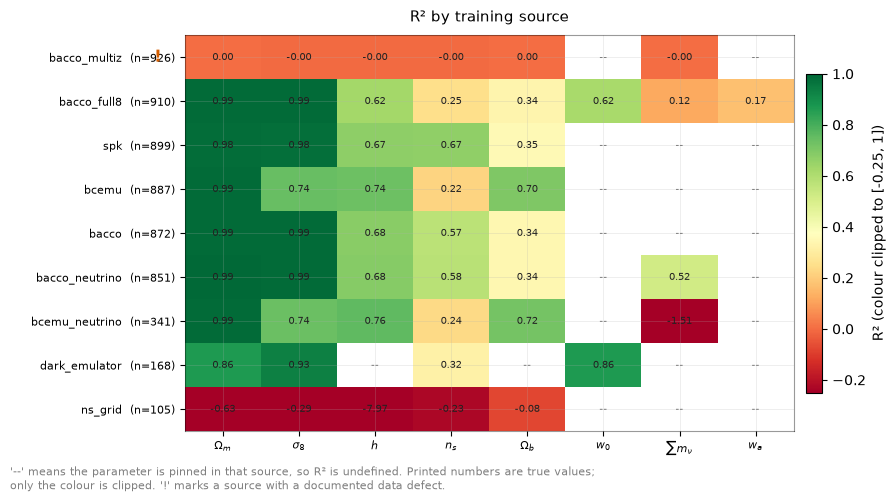

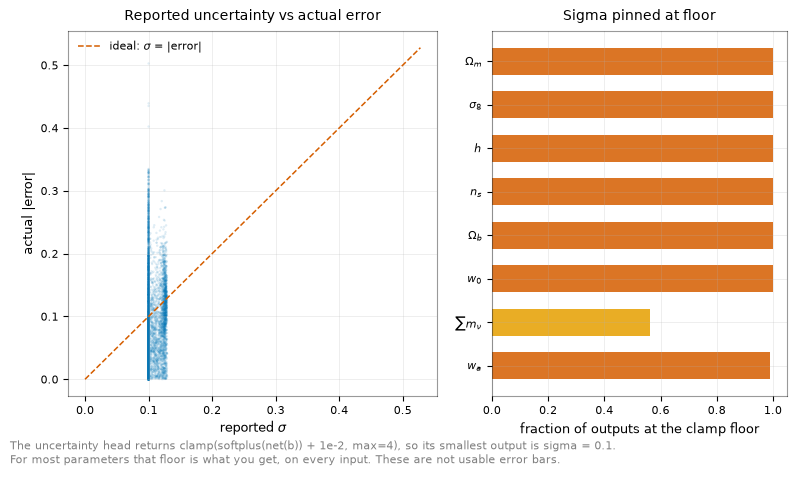

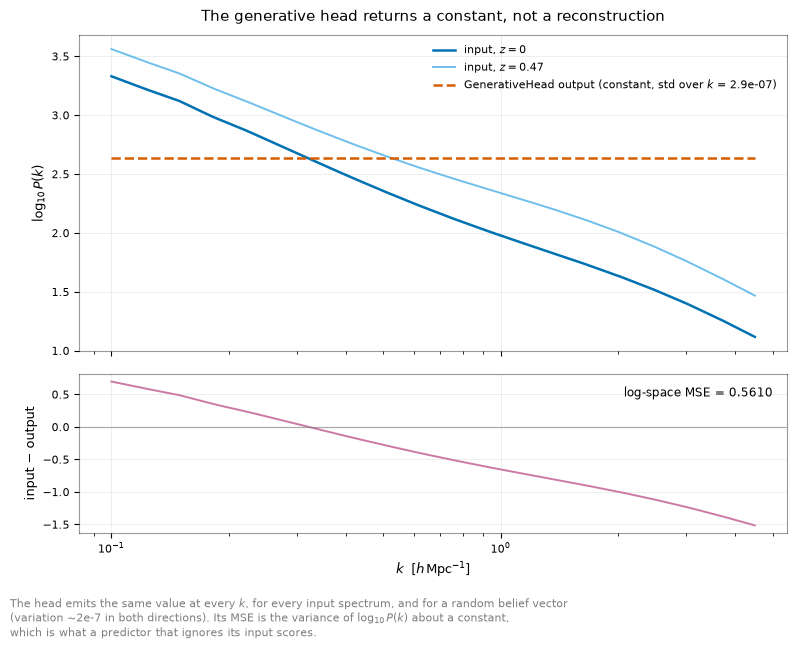

In [10]:
%matplotlib inline
from cosmufr import figures as F

F.fig_weight_audit(audit)
F.fig_settling_trajectory(report)
F.fig_parameter_recovery(ev)
F.fig_per_source(ev)
F.fig_uncertainty_audit(ev)
F.fig_pk_reconstruction(bench.k_bins, bench.pk_z0[i], bench.pk_z047[i],
                        result.pk_recon, result.log_k)
None

## 6. Bring your own P(k)

The model expects `P(k)` on 200 log-spaced bins over k from 0.1 to 4.5 h/Mpc, at z = 0 and z = 0.47. Raw `P(k)` and `log10 P(k)` are both accepted and auto-detected.

The helper below tells you precisely what is wrong with an input rather than failing obscurely.

In [11]:
K_GRID = np.logspace(np.log10(0.1), np.log10(4.5), 200)

def validate_input(pk_z0, pk_z047, k=None):
    """Return a list of problems with an input pair. Empty list means it is fine."""
    problems = []
    for name, a in [('pk_z0', pk_z0), ('pk_z047', pk_z047)]:
        a = np.asarray(a)
        if a.ndim != 1:
            problems.append(f'{name}: expected 1-D, got shape {a.shape}')
            continue
        if a.size != 200:
            problems.append(f'{name}: expected 200 k-bins, got {a.size}. '
                            f'Interpolate onto K_GRID first.')
        if not np.isfinite(a).all():
            problems.append(f'{name}: contains NaN or inf')
        if np.isfinite(a).all() and (a <= 0).any() and (a > 100).any():
            problems.append(f'{name}: mixes non-positive and large values; '
                            f'pass either raw P(k) > 0 or log10 P(k)')
    if k is not None:
        k = np.asarray(k)
        if k.size == 200 and not np.allclose(k, K_GRID, rtol=0.02):
            problems.append('k grid differs from the training grid by more than '
                            '2 percent. Interpolate log10 P(k) onto K_GRID.')
    return problems

def to_training_grid(k_src, pk_src):
    """Log-log interpolation onto the 200-bin training grid."""
    return np.exp(np.interp(np.log(K_GRID), np.log(k_src), np.log(pk_src)))

# Example: your own spectrum on your own grid.
my_k = np.logspace(np.log10(0.05), np.log10(8.0), 87)
my_pk_z0 = 2e4 * my_k ** -1.6
my_pk_z047 = 0.62 * my_pk_z0

pk0_i = to_training_grid(my_k, my_pk_z0)
pk047_i = to_training_grid(my_k, my_pk_z047)

problems = validate_input(pk0_i, pk047_i, K_GRID)
print('problems:', problems or 'none')

if not problems:
    r = cosmufr.infer(pk0_i, pk047_i, model=model)
    for lbl, v in r.params.items():
        print(f'  {lbl:<4}{v:>10.5f}')
    print('\nsigmas omitted: they are the clamp floor, not a prediction.')

problems: none
  Om     0.31957
  s8     0.82342
  h      0.73998
  ns     0.98913
  Ob     0.04875
  w0    -0.97342
  mv     0.22897
  wa     0.00319

sigmas omitted: they are the clamp floor, not a prediction.


## 7. Limitations

Stated in full.

1. `obs_encoder`, `belief_proposal` and `settling` never trained. The architecture's central claim is unsupported by its own weights.
2. Settling does no measurable work: 0.09 percent belief movement, energy flat to one float32 unit.
3. Uncertainties are the clamp constant 0.1 for six of eight parameters on 100 percent of inputs. The reported ECE of 0.39 follows directly.
4. Neutrino mass is not recovered, R-squared 0.011 where it varies.
5. The energy subsystem diverged. `E_con` is around -4.6e5 and is not a usable out-of-distribution signal.
6. Two redshifts only. Multi-redshift generalization is unvalidated.
7. **No baseline and no ablation.** There is no comparison against an amortized posterior estimator or a plain MLP. That is the first thing a reviewer should ask for, and it does not exist yet.
8. Historical cross-run comparisons in this project's development logs are untrustworthy, because epoch-to-epoch R-squared noise of plus or minus 0.03 to 0.10 was never controlled for.
9. The generative head collapsed to a constant. `result.pk_recon` is 2.6327 at every k, for every input spectrum, and even for a random belief vector. Its MSE of 0.687 is the variance of log10 P(k) about a constant, which is what a predictor that ignores its input scores.

Full detail: [README](https://github.com/arajgor1/cosmufr-run4) and `reports/honest_eval.json`.